# RQ2-Analyse — RAG-Konfigurations-Vergleich

Wertet die Konfigurations-Läufe aus (Versionsnamen mit `__`). Vergleicht die
**Retrieval-Qualität** je Konfiguration anhand von `TurnContextualRelevancy` und
`TurnFaithfulness` sowie der **Retrieval-Abdeckung** (Anteil Antworten mit Kontext,
aus den Konversations-JSONs).

> Bei fehlenden Paketen: `pip install pandas matplotlib`


In [16]:
import glob, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Pfade (ggf. anpassen) ----
CSV_GLOB  = "../persistence/csv/eval_rohdaten_system_prompt__*.csv"          # nur RQ2 (mit __)
CONV_GLOB = "../persistence/konversationen/konversationen_*__*.json"
RAG_METRIKEN = ["Turn Contextual Relevancy", "Turn Faithfulness"]
NEEDED = ["prompt_version", "conversation_id", "metric", "score"]
print(CSV_GLOB, "eval_rohdaten_system_prompt__beide_hybrid")

../persistence/csv/eval_rohdaten_system_prompt__*.csv eval_rohdaten_system_prompt__beide_hybrid


## 1. RQ2-Rohdaten laden

In [17]:
files = glob.glob(CSV_GLOB)
if not files:
    raise FileNotFoundError(f"Keine RQ2-CSVs unter {CSV_GLOB} gefunden. "
                            "Wurde die Evaluation (RUN_EVALUATION=true) fuer rq2 gelaufen?")
print("Gefundene RQ2-CSVs:", files)
df = pd.concat(
    [pd.read_csv(f, encoding="utf-8-sig", engine="python", usecols=lambda c: c in NEEDED) for f in files],
    ignore_index=True,
)
df["score"]  = pd.to_numeric(df["score"], errors="coerce")
df["metrik"] = df["metric"].astype(str).str.strip()
df["config"] = df["prompt_version"].astype(str).str.split("__").str[1]
print("Konfigurationen:", sorted(df["config"].unique()))
df.head()

Gefundene RQ2-CSVs: ['../persistence/csv\\eval_rohdaten_system_prompt__labor_dense.csv', '../persistence/csv\\eval_rohdaten_system_prompt__llm_only.csv', '../persistence/csv\\eval_rohdaten_system_prompt__vorlesung_dense.csv']
Konfigurationen: ['labor_dense', 'llm_only']


,prompt_version,conversation_id,metric,score,metrik,config
0,system_prompt__labor_dense,c33bdac774,Turn Contextual Relevancy,1.000000,Turn Contextual Relevancy,labor_dense
1,system_prompt__labor_dense,c33bdac774,Turn Faithfulness,0.931188,Turn Faithfulness,labor_dense
2,system_prompt__labor_dense,8ef8f29a4a,Turn Contextual Relevancy,1.000000,Turn Contextual Relevancy,labor_dense
3,system_prompt__labor_dense,8ef8f29a4a,Turn Faithfulness,0.987210,Turn Faithfulness,labor_dense
4,system_prompt__labor_dense,8b1f8d9ee5,Turn Contextual Relevancy,1.000000,Turn Contextual Relevancy,labor_dense


## 2. RAG-Metriken je Konfiguration (Mittelwert, Std, n)

In [18]:
rag = df[df["metrik"].isin(RAG_METRIKEN)].dropna(subset=["score"])
stats = (rag.groupby(["config", "metrik"])["score"]
         .agg(n="count", mean="mean", std="std")
         .round(3))
stats
print(df["metrik"].unique())

<StringArray>
['Turn Contextual Relevancy', 'Turn Faithfulness']
Length: 2, dtype: str


## 3. Vergleich der Konfigurationen (Balken je RAG-Metrik)

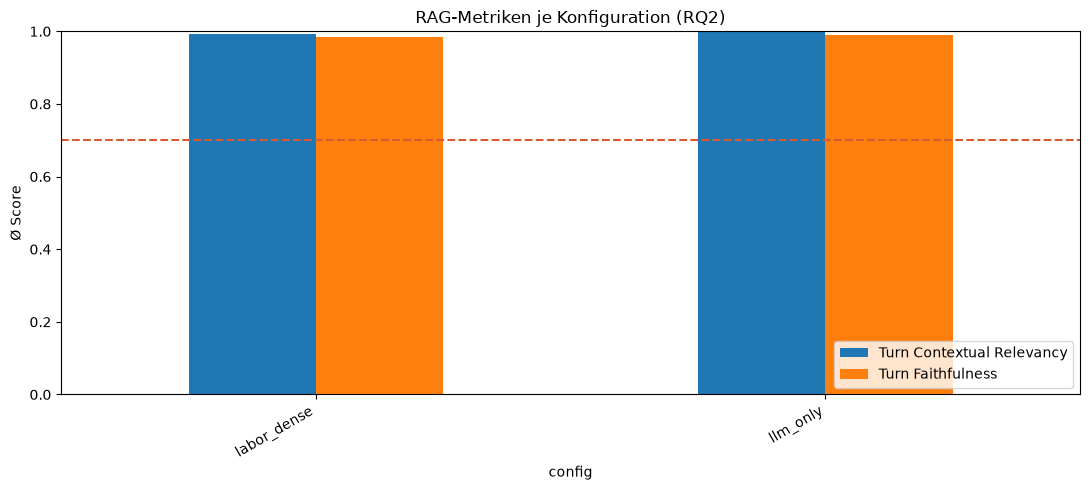

metrik,Turn Contextual Relevancy,Turn Faithfulness
config,,
labor_dense,0.992,0.985
llm_only,1.000,0.991


In [19]:
piv = rag.pivot_table(index="config", columns="metrik", values="score", aggfunc="mean").round(3)
ax = piv.plot(kind="bar", figsize=(11, 5))
ax.axhline(0.7, color="#d85a30", ls="--")
ax.set_ylim(0, 1); ax.set_ylabel("Ø Score"); ax.set_title("RAG-Metriken je Konfiguration (RQ2)")
ax.legend(loc="lower right"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
piv

## 4. Retrieval-Abdeckung je Konfiguration

Aus den Konversations-JSONs: Anteil der Assistant-Antworten mit tatsächlich abgerufenem
`retrieval_context`. Der wichtigste label-freie Indikator, ob eine Konfiguration
überhaupt Kontext liefert.

In [20]:
rows = []
for f in glob.glob(CONV_GLOB):
    version = os.path.basename(f).replace("konversationen_", "").replace(".json", "")
    config = version.split("__")[1] if "__" in version else version
    d = json.load(open(f, encoding="utf-8"))
    tot = wc = 0
    for c in d:
        for t in c["turns"]:
            if t["role"] == "assistant":
                tot += 1
                if t.get("retrieval_context"):
                    wc += 1
    rows.append({"config": config, "antworten": tot, "mit_kontext": wc,
                 "abdeckung_%": round(wc / tot * 100) if tot else 0})
cov = pd.DataFrame(rows).sort_values("abdeckung_%", ascending=False).reset_index(drop=True)
cov

,config,antworten,mit_kontext,abdeckung_%
0,beide_sparse,167,167,100
1,beide_hybrid_rerank,167,139,83
2,labor_hybrid_rerank,165,132,80
3,vorlesung_hybrid_rerank,165,123,75
4,beide_hybrid,164,41,25
5,labor_dense,166,3,2
6,beide_dense,168,0,0
7,llm_only,167,0,0
8,vorlesung_dense,165,0,0


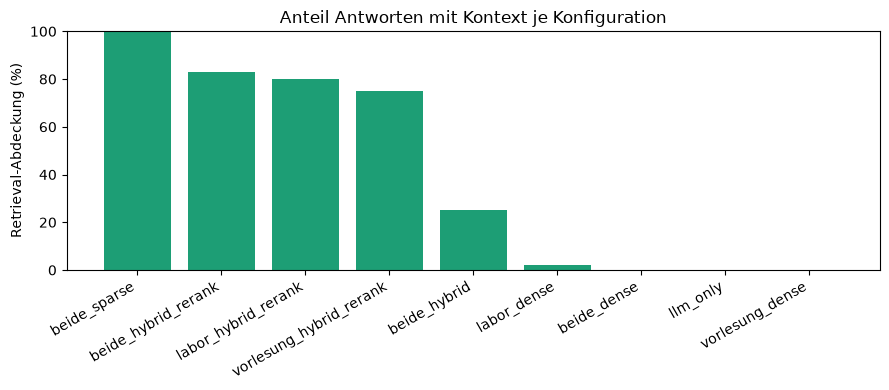

In [21]:
plt.figure(figsize=(9, 4))
plt.bar(cov["config"], cov["abdeckung_%"], color="#1d9e75")
plt.ylabel("Retrieval-Abdeckung (%)"); plt.title("Anteil Antworten mit Kontext je Konfiguration")
plt.xticks(rotation=30, ha="right"); plt.ylim(0, 100); plt.tight_layout(); plt.show()

## 5. Gesamtranking je Konfiguration

In [22]:
rang = piv.copy()
rang = rang.merge(cov.set_index("config")[["abdeckung_%"]], left_index=True, right_index=True, how="left")
rang = rang.sort_values(RAG_METRIKEN[0], ascending=False)
rang

,Turn Contextual Relevancy,Turn Faithfulness,abdeckung_%
config,,,
llm_only,1.000,0.991,0
labor_dense,0.992,0.985,2


## 6. Ergebnisse speichern

In [23]:
stats.to_csv("rq2_metrik_stats.csv")
rang.to_csv("rq2_konfiguration_ranking.csv")
cov.to_csv("rq2_retrieval_abdeckung.csv", index=False)
print("gespeichert: rq2_metrik_stats.csv, rq2_konfiguration_ranking.csv, rq2_retrieval_abdeckung.csv")

gespeichert: rq2_metrik_stats.csv, rq2_konfiguration_ranking.csv, rq2_retrieval_abdeckung.csv


In [24]:
# Metrik-Mittelwerte je Config (aus den RQ2-Eval-CSVs)
m = (df[df.metrik.isin(RAG_METRIKEN)].dropna(subset=["score"])
     .pivot_table(index="config", columns="metrik", values="score", aggfunc="mean"))

# mit der Abdeckung zusammenfuehren
comb = m.merge(cov.set_index("config")[["abdeckung_%"]], left_index=True, right_index=True)
comb["abdeckung"] = comb["abdeckung_%"] / 100
comb["eff_relevanz"]     = (comb["abdeckung"] * comb["Turn Contextual Relevancy"]).round(3)
comb["eff_faithfulness"] = (comb["abdeckung"] * comb["Turn Faithfulness"]).round(3)
comb.sort_values("eff_relevanz", ascending=False)

,Turn Contextual Relevancy,Turn Faithfulness,abdeckung_%,abdeckung,eff_relevanz,eff_faithfulness
config,,,,,,
labor_dense,0.991623,0.984817,2,0.02,0.02,0.02
llm_only,1.000000,0.991024,0,0.00,0.00,0.00


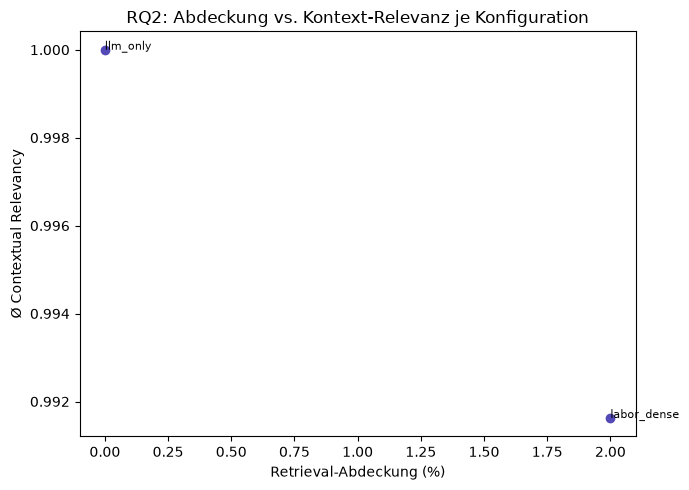

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(comb["abdeckung_%"], comb["Turn Contextual Relevancy"], color="#534ab7")
for c, r in comb.iterrows():
    plt.annotate(c, (r["abdeckung_%"], r["Turn Contextual Relevancy"]), fontsize=8)
plt.xlabel("Retrieval-Abdeckung (%)"); plt.ylabel("Ø Contextual Relevancy")
plt.title("RQ2: Abdeckung vs. Kontext-Relevanz je Konfiguration"); plt.tight_layout(); plt.show()

In [26]:
import glob, os, json
grounded = {}
for f in glob.glob(CONV_GLOB):
    d = json.load(open(f, encoding="utf-8"))
    for c in d:
        cid = (c.get("meta") or {}).get("conversation_id")
        grounded[cid] = any(
            t["role"] == "assistant" and t.get("retrieval_context") for t in c["turns"]
        )

df["grounded"] = df["conversation_id"].map(grounded)

grounded_only = (df[df.metrik.isin(RAG_METRIKEN) & df["grounded"]]
                 .dropna(subset=["score"])
                 .pivot_table(index="config", columns="metrik", values="score", aggfunc="mean")
                 .round(3))
grounded_only

metrik,Turn Contextual Relevancy,Turn Faithfulness
config,,
labor_dense,0.899,0.978
